In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

df = pd.read_csv('../data/processed/investments_VC_cleaned.csv')
df

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,/organization/waywire,#waywire,http://www.waywire.com,Entertainment|Politics|Social Media|News,News,1750000.00,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,Games,Games,4000000.00,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,Publishing|Education,Publishing,40000.00,operating,EST,Unknown,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,Electronics|Guides|Coffee|Restaurants|Music|Ip...,Electronics,1500000.00,operating,GBR,MA,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,Unknown,Tourism|Entertainment|Games,Tourism,60000.00,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49431,/organization/zzish,Zzish,http://www.zzish.com,Analytics|Gamification|Developer Apis|Ios|Andr...,Education,320000.00,operating,GBR,MA,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49432,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,Enterprise Software,1587301.00,operating,CHN,Unknown,Beijing,...,0.0,0.0,1587301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49433,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,Web Development|Advertising|Wireless|Mobile,Web Development,97398.00,operating,HRV,Unknown,Split,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49434,/organization/a-list-games,[a]list games,http://www.alistgames.com,Games,Games,9300000.00,operating,Unknown,Unknown,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_known = df[df['status'] != 'unknown'].copy()
df_known['is_success'] = df_known['status'].isin(['operating', 'acquired']).astype(int)
print('Known status rows: ' + str(len(df_known)))

Known status rows: 49436


In [4]:
df_known['founded_at'] = pd.to_datetime(df_known['founded_at'], errors='coerce')
df_known['first_funding_at'] = pd.to_datetime(df_known['first_funding_at'], errors='coerce')

df_known['time_to_first_funding_days'] = (df_known['first_funding_at'] - df_known['founded_at']).dt.days

df_known.dropna(subset=['time_to_first_funding_days'], inplace=True)

print('New column \'time_to_first_funding_days\' added to df_known.')

New column 'time_to_first_funding_days' added to df_known.


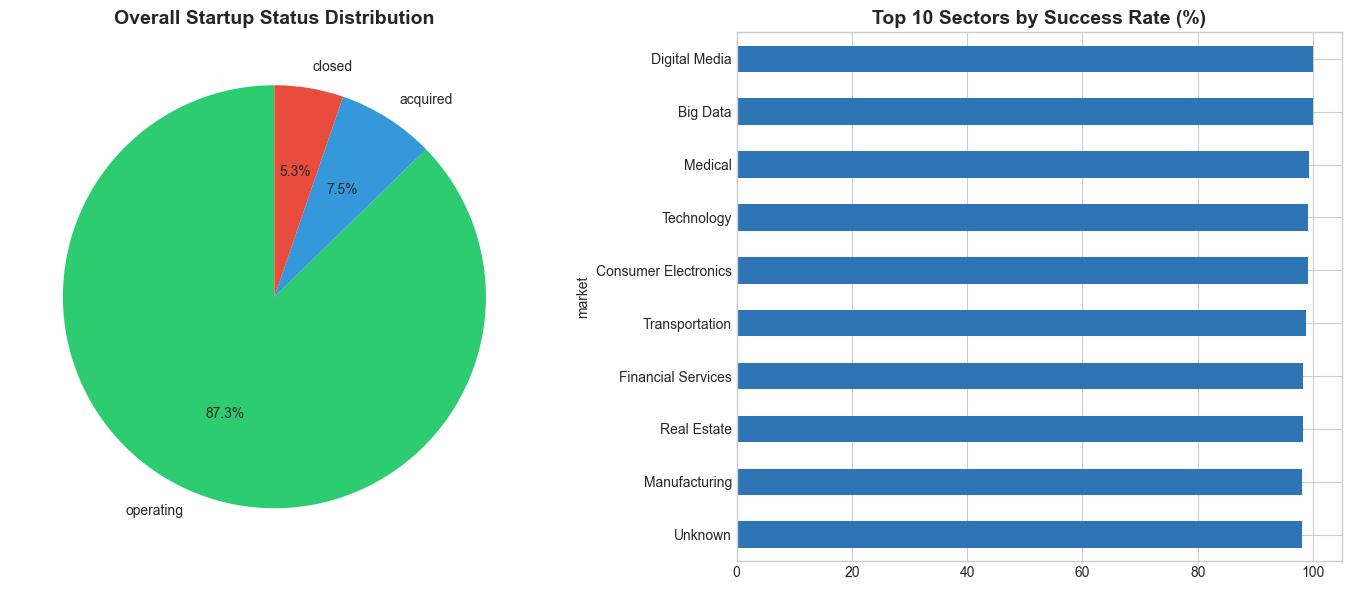

INSIGHT: Overall success rate = 94.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

status_counts = df['status'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Overall Startup Status Distribution', fontsize=14, fontweight='bold')

sector_success = df_known.groupby('market')['is_success'].agg(['mean','count'])
sector_success = sector_success[sector_success['count'] >= 100]
sector_success = sector_success.sort_values('mean', ascending=True).tail(10)
sector_success['mean'].mul(100).plot(kind='barh', ax=axes[1], color='#2E75B6')
axes[1].set_title('Top 10 Sectors by Success Rate (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/eda_block1_status.png', dpi=150, bbox_inches='tight')
plt.show()

overall_rate = df_known['is_success'].mean() * 100
print('INSIGHT: Overall success rate = ' + str(round(overall_rate, 1)) + '%')

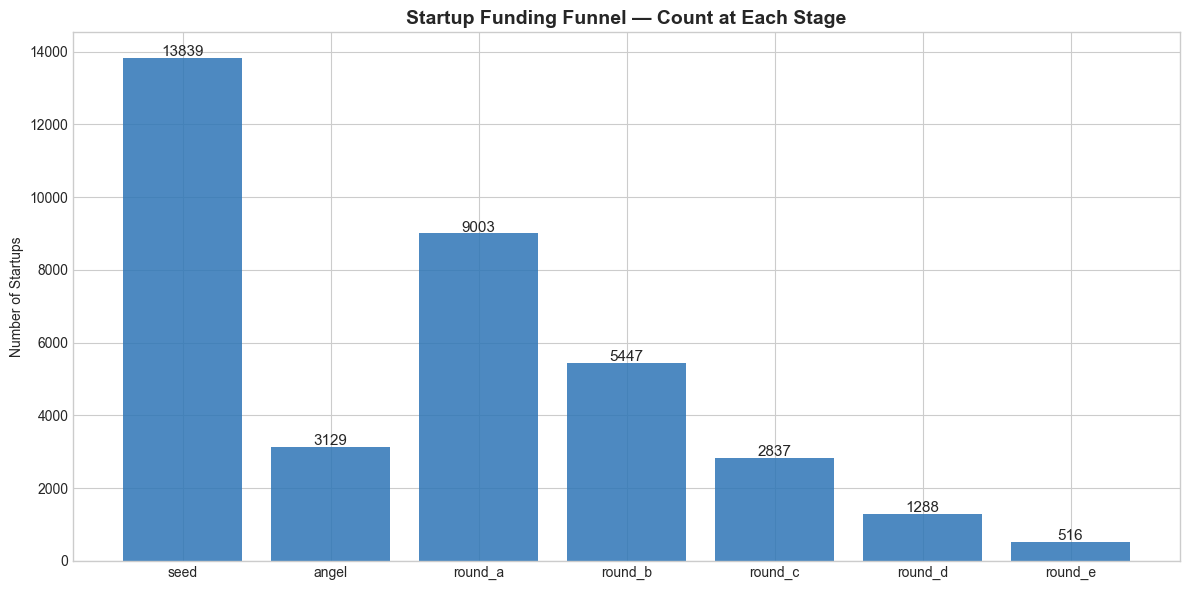

INSIGHT: Of 13839 seed-funded startups, only 9003 (65.1%) reached Series A


In [6]:
round_cols = ['seed', 'angel', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e']
funnel = {col: (df[col] > 0).sum() for col in round_cols}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(list(funnel.keys()), list(funnel.values()), color='#2E75B6', alpha=0.85)
ax.set_title('Startup Funding Funnel — Count at Each Stage', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Startups')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(bar.get_height())), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/eda_block2_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

seed_n = funnel['seed']
serA_n = funnel['round_a']
print('INSIGHT: Of ' + str(seed_n) + ' seed-funded startups, only ' + str(serA_n) + ' (' + str(round(serA_n/seed_n*100,1)) + '%) reached Series A')

TOP 10 SECTORS BY SUCCESS RATE:
                   market  count  success_rate_pct   avg_funding
183         Digital Media    103        100.000000  3.147696e+06
50               Big Data    151        100.000000  4.880294e+06
421               Medical    260         99.230769  3.266126e+06
676            Technology    254         99.212598  6.839780e+06
124  Consumer Electronics    110         99.090909  3.575038e+06
697        Transportation    162         98.765432  4.712397e+06
259    Financial Services    114         98.245614  4.732130e+06
560           Real Estate    394         98.223350  3.353096e+06
411         Manufacturing    744         98.118280  5.678715e+06
708               Unknown   3960         98.030303  1.759064e+06


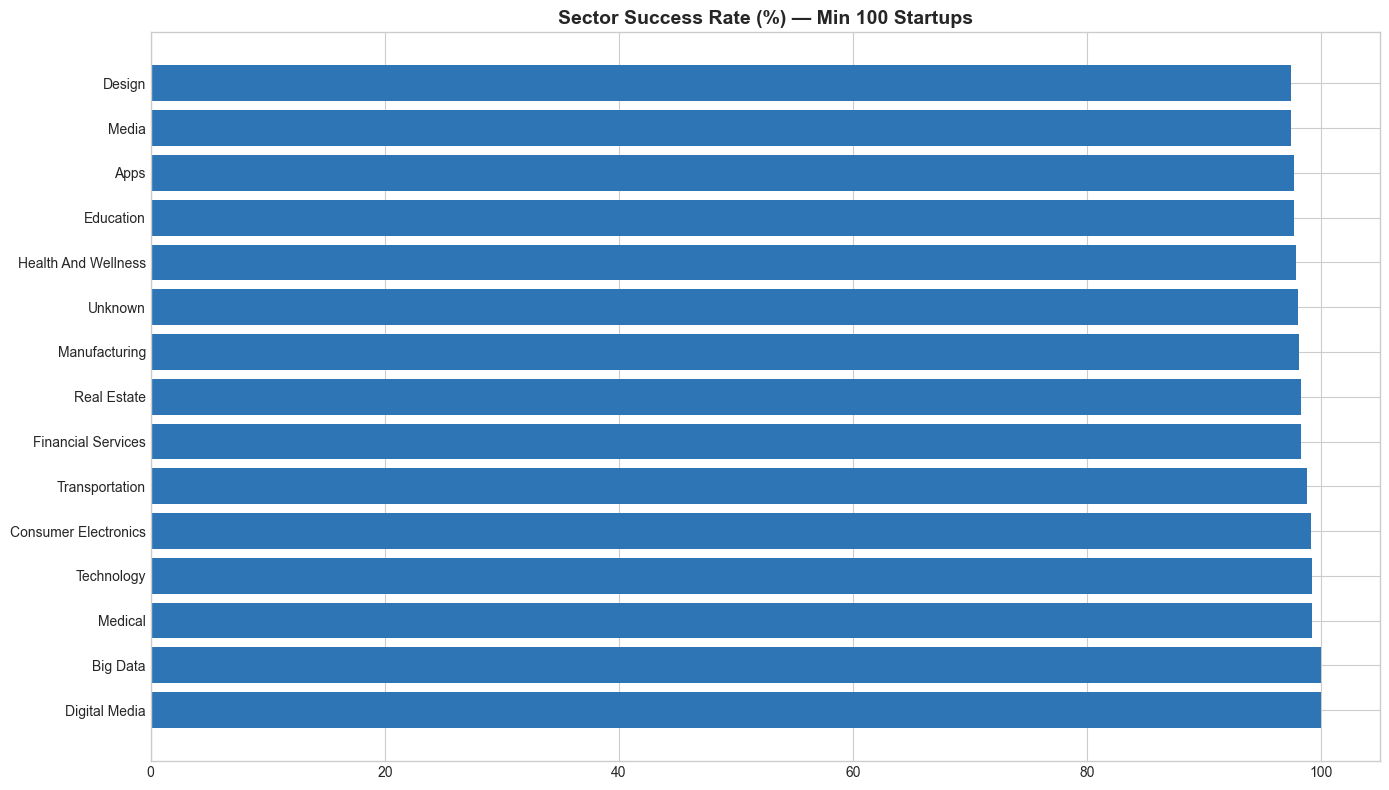

In [7]:
sector_stats = df_known.groupby('market').agg(
    count=('is_success', 'count'),
    success_rate=('is_success', 'mean'),
    avg_funding=('funding_total_usd', 'mean')
).reset_index()

sector_stats = sector_stats[sector_stats['count'] >= 100].copy()
sector_stats['success_rate_pct'] = sector_stats['success_rate'] * 100
sector_stats = sector_stats.sort_values('success_rate_pct', ascending=False)

print('TOP 10 SECTORS BY SUCCESS RATE:')
print(sector_stats[['market','count','success_rate_pct','avg_funding']].head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
top15 = sector_stats.head(15)
ax.barh(top15['market'], top15['success_rate_pct'], color='#2E75B6')
ax.set_title('Sector Success Rate (%) — Min 100 Startups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_block3_sectors.png', dpi=150, bbox_inches='tight')
plt.show()

TOP 15 COUNTRIES BY SUCCESS RATE:
    country_code  count  success_rate_pct   avg_funding
9            BGR     68        100.000000  7.567292e+05
58           KOR    246         99.186992  2.287402e+06
19           CHL    285         98.596491  1.798383e+05
89           PRT     69         98.550725  2.011275e+06
104          TUR    124         98.387097  2.788772e+06
27           CZE     51         98.039216  2.560645e+06
55           JPN    284         97.887324  3.957701e+06
20           CHN   1239         97.094431  8.238326e+06
88           POL     94         96.808511  1.486572e+06
18           CHE    222         96.396396  5.529071e+06
47           IND    849         96.113074  5.090781e+06
51           ITA    308         96.103896  1.886861e+06
36           FIN    194         95.876289  3.620943e+06
79           NLD    307         95.765472  3.911722e+06
4            AUS    314         95.541401  3.746072e+06


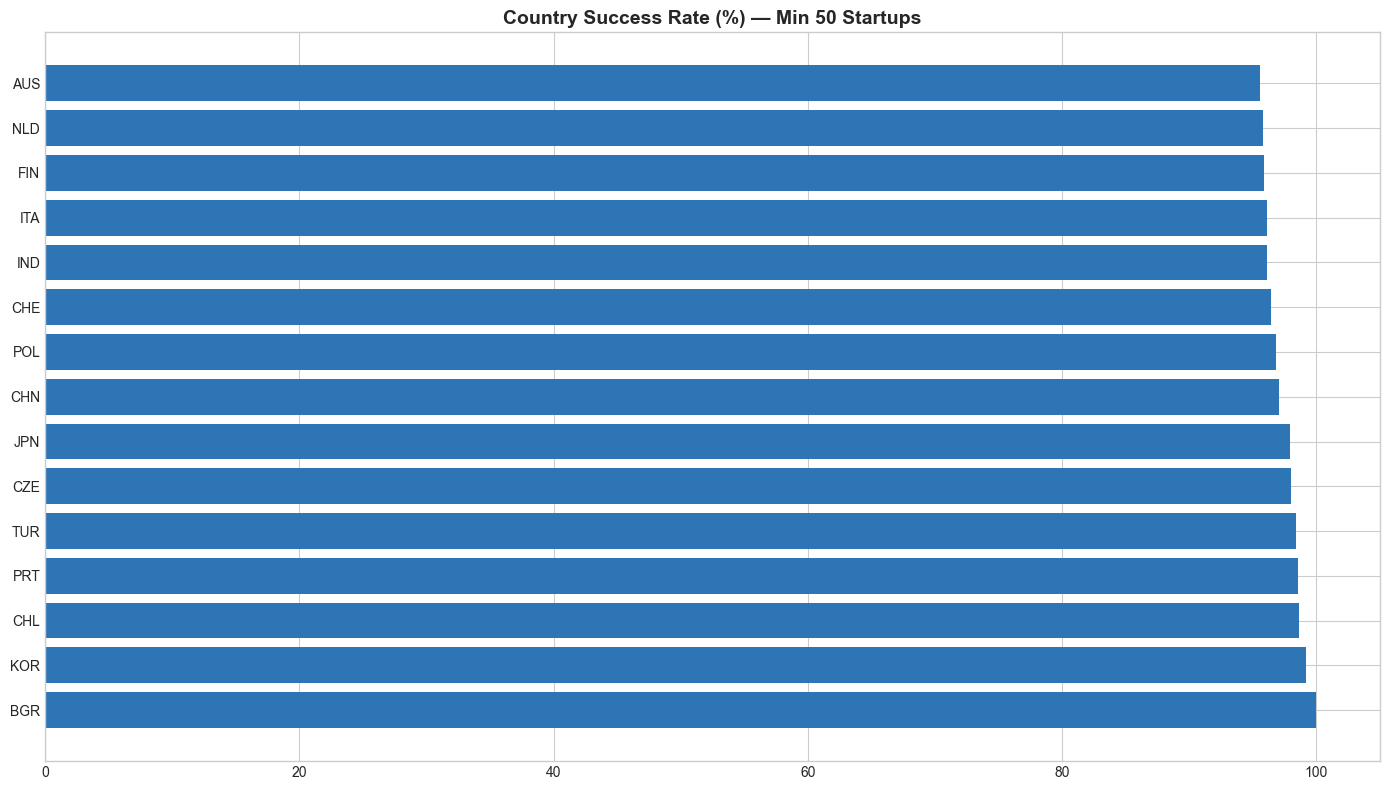

In [8]:
country_stats = df_known.groupby('country_code').agg(
    count=('is_success', 'count'),
    success_rate=('is_success', 'mean'),
    avg_funding=('funding_total_usd', 'mean')
).reset_index()

country_stats = country_stats[country_stats['count'] >= 50]
country_stats['success_rate_pct'] = country_stats['success_rate'] * 100
country_stats = country_stats.sort_values('success_rate_pct', ascending=False)

print('TOP 15 COUNTRIES BY SUCCESS RATE:')
print(country_stats[['country_code','count','success_rate_pct','avg_funding']].head(15).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(country_stats.head(15)['country_code'],
        country_stats.head(15)['success_rate_pct'], color='#2E75B6')
ax.set_title('Country Success Rate (%) — Min 50 Startups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_block4_geography.png', dpi=150, bbox_inches='tight')
plt.show()

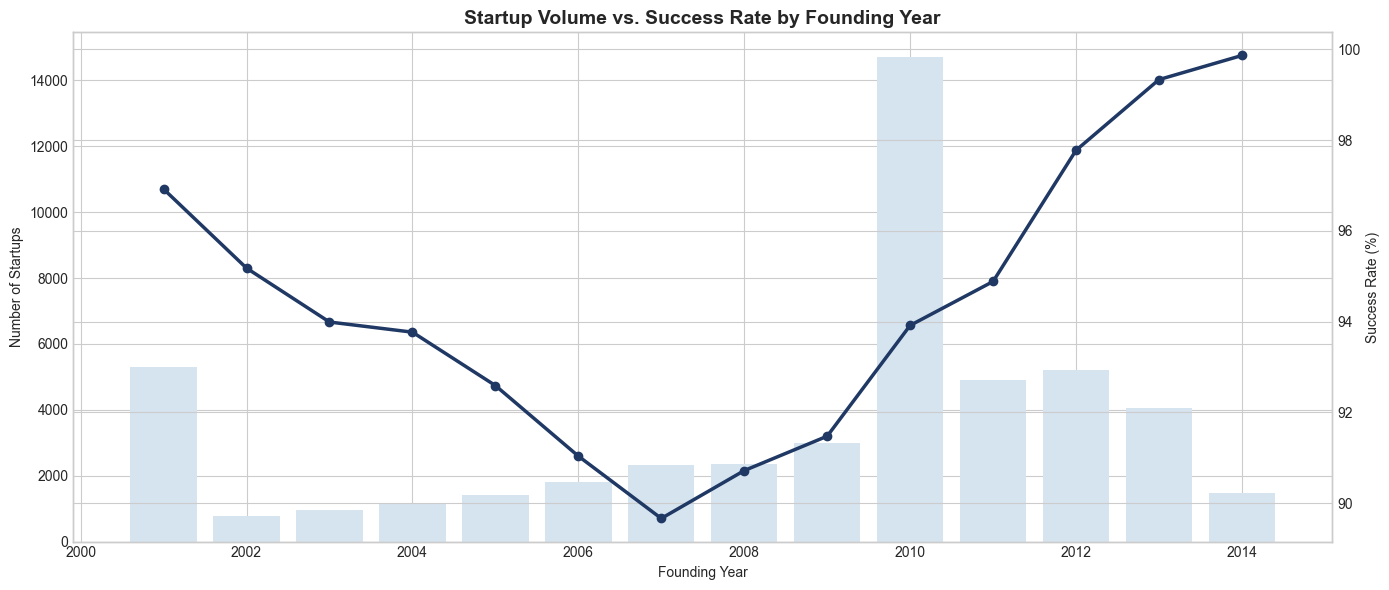

Successful: 596 days to first funding
Failed: 145 days to first funding


In [9]:
year_stats = df_known[df_known['founded_year'].between(1990, 2014)].groupby('founded_year').agg(
    count=('is_success', 'count'),
    success_rate=('is_success', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(year_stats['founded_year'], year_stats['count'], color='#D6E4F0', label='Deal Count')
ax2.plot(year_stats['founded_year'], year_stats['success_rate']*100,
         color='#1F3864', linewidth=2.5, marker='o', label='Success Rate %')

ax1.set_xlabel('Founding Year')
ax1.set_ylabel('Number of Startups')
ax2.set_ylabel('Success Rate (%)')
ax1.set_title('Startup Volume vs. Success Rate by Founding Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_block5_vintage.png', dpi=150, bbox_inches='tight')
plt.show()

ttf = df_known.groupby('is_success')['time_to_first_funding_days'].median()
print('Successful: ' + str(round(ttf.get(1, 0))) + ' days to first funding')
print('Failed: ' + str(round(ttf.get(0, 0))) + ' days to first funding')